In [1]:
# ==== HARD REPRO LOCK (put in the very first cell) ====
import os, random, numpy as np, torch
SEED = 2024  

# 1) env vars — 一定要在建立任何東西之前設定
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"  # CUDA matmul 決定論

# 2) 全域亂數源
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# 3) cuDNN / 算法選擇（決定論）
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception:
    pass

# 4) DataLoader 專用 generator & worker seeding
g = torch.Generator().manual_seed(SEED)
def seed_worker(worker_id):
    base = SEED + worker_id
    np.random.seed(base)
    random.seed(base)
    torch.manual_seed(base)

print("✅ HARD REPRO LOCK enabled, SEED =", SEED)


✅ HARD REPRO LOCK enabled, SEED = 2024


In [2]:
!pip -q install pydicom torch torchvision scikit-learn pandas matplotlib pillow

from pathlib import Path
import os, random, numpy as np, pandas as pd, matplotlib.pyplot as plt
import pydicom, torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18, ResNet18_Weights
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# ←←← 改成你的資料夾
DATA_DIR = Path(r"C:\研究所\深度學習\hwk02_data")
TRAIN_CSV = DATA_DIR/"train.csv"
TEST_CSV  = DATA_DIR/"test.csv"
DICOM_DIR = DATA_DIR/"DICOM"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)
print("存在檢查：", TRAIN_CSV.exists(), TEST_CSV.exists(), DICOM_DIR.exists())


device = cpu
存在檢查： True True True


In [3]:
# ---- SAFEGUARD: ensure train_df / test_df are loaded before path resolution ----
try:
    _ = train_df, test_df  # type: ignore
except NameError:
    import pandas as pd
    from pathlib import Path
    # Try common variable names if defined; otherwise fall back to default filenames.
    if "TRAIN_CSV" in globals():
        _train_csv = TRAIN_CSV
    else:
        _train_csv = Path("train.csv")
    if "TEST_CSV" in globals():
        _test_csv = TEST_CSV
    else:
        _test_csv = Path("test.csv")
    train_df = pd.read_csv(_train_csv)
    test_df = pd.read_csv(_test_csv)
    print(f"[Guard] Loaded train/test from {_train_csv} / {_test_csv}")
# ----------------------------------------------------------------------------


[Guard] Loaded train/test from C:\研究所\深度學習\hwk02_data\train.csv / C:\研究所\深度學習\hwk02_data\test.csv


In [4]:
from pathlib import Path

def resolve_dicom_path(file_path_str: str, data_root: Path, data_dir: Path) -> Path | None:
    # 原字串
    s = str(file_path_str).strip()

    # 1) 先把前導 / 或 \ 拿掉（避免被當成磁碟根目錄）
    s_stripped = s.lstrip("/\\")
    p0 = Path(s)               # 原樣
    p1 = Path(s_stripped)      # 去掉前導斜線
    # 2) 一系列候選：原樣、DICOM_DIR 之下、DATA_DIR 之下
    cands = [
        p0, p1,
        data_root / p0, data_root / p1,
        data_dir  / p0, data_dir  / p1,
    ]
    for q in cands:
        if q.exists():
            return q.resolve()

    return None  # 找不到就回傳 None

# 應用到 train/test，產生 ResolvedPath 欄
train_df["ResolvedPath"] = train_df["FilePath"].apply(lambda s: resolve_dicom_path(s, DICOM_DIR, DATA_DIR))
test_df["ResolvedPath"]  = test_df["FilePath"].apply(lambda s: resolve_dicom_path(s, DICOM_DIR, DATA_DIR))

print("無法解析的 train/test 路徑：",
      train_df["ResolvedPath"].isna().sum(), "/",
      test_df["ResolvedPath"].isna().sum())

# 顯示幾筆對照檢查
display(train_df.loc[train_df["ResolvedPath"].notna(), ["ID","FilePath","ResolvedPath"]].head())

# 丟掉找不到檔案的列（若有）
train_df = train_df.dropna(subset=["ResolvedPath"]).reset_index(drop=True)
test_df  = test_df.dropna(subset=["ResolvedPath"]).reset_index(drop=True)


無法解析的 train/test 路徑： 0 / 0


,ID,FilePath,ResolvedPath
0,A175204,/DICOM/A175204/00010018,C:\研究所\深度學習\hwk02_data\DICOM\A175204\00010018
1,A122221,/DICOM/A122221/00010034,C:\研究所\深度學習\hwk02_data\DICOM\A122221\00010034
2,A54671,/DICOM/A54671/00010021,C:\研究所\深度學習\hwk02_data\DICOM\A54671\00010021
3,A31117,/DICOM/A31117/00010022,C:\研究所\深度學習\hwk02_data\DICOM\A31117\00010022
4,A653195,/DICOM/A653195/00010016,C:\研究所\深度學習\hwk02_data\DICOM\A653195\00010016


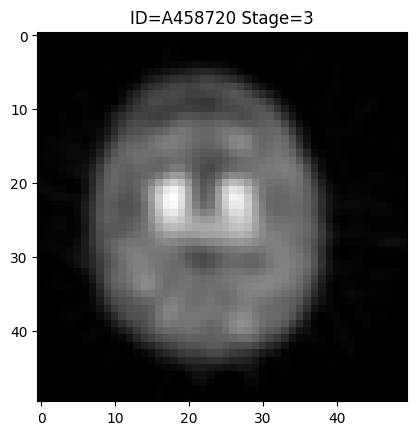

In [5]:
import pydicom, numpy as np

def load_volume(file_or_dir: Path):
    """回傳 3D 體素陣列 (Z,H,W) 或 2D (H,W) 若只有單張。支援：
       1) 單一 DICOM 檔（可能是 multi-frame）
       2) 一個資料夾，裡面多個 .dcm（單張檔）"""
    p = Path(file_or_dir)
    if p.is_file():
        ds = pydicom.dcmread(str(p))
        arr = ds.pixel_array
        return arr
    if p.is_dir():
        # 讀取資料夾內所有 DICOM 檔（副檔名可能沒有 .dcm，也一併嘗試）
        files = sorted([q for q in p.iterdir() if q.is_file()])
        frames = []
        for f in files:
            try:
                ds = pydicom.dcmread(str(f))
                frames.append(ds.pixel_array)
            except Exception:
                continue
        if len(frames) == 0:
            raise FileNotFoundError(f"No readable DICOM in folder: {p}")
        arr = np.stack(frames, axis=0) if frames[0].ndim == 2 else np.array(frames)
        return arr
    raise FileNotFoundError(f"Path not found: {p}")

def read_frame_by_index(file_path: Path, z_index: int):
    vol = load_volume(file_path)  # 可能是 2D 或 3D
    if vol.ndim == 2:
        return vol
    Z,H,W = vol.shape
    z = max(0, min(int(z_index), Z-1))
    return vol[z]

def three_slices_to_3ch(file_path: Path, z_index: int):
    vol = load_volume(file_path)
    if vol.ndim == 2:
        s = vol
        return np.stack([s,s,s], axis=-1)
    Z,H,W = vol.shape
    z  = max(0, min(int(z_index), Z-1))
    z0 = max(0, z-1); z2 = min(Z-1, z+1)
    return np.stack([vol[z0], vol[z], vol[z2]], axis=-1)

def center_crop(img: np.ndarray, size=50):
    h,w = img.shape[:2]
    sh, sw = h//2 - size//2, w//2 - size//2
    return img[sh:sh+size, sw:sw+size]

def img_to_uint8(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    lo, hi = np.percentile(x, [1,99])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi<=lo:
        lo, hi = float(x.min()), float(x.max())
    if hi<=lo:
        return np.zeros_like(x, dtype=np.uint8)
    x = (x - lo) / (hi - lo)
    x = np.clip(x, 0, 1) * 255.0
    return x.astype(np.uint8)

# 快速抽樣檢查（**注意：這裡要用 ResolvedPath，不是 FilePath**）
for i in np.random.choice(len(train_df), size=min(1, len(train_df)), replace=False):
    r = train_df.iloc[i]
    arr3 = center_crop(three_slices_to_3ch(r["ResolvedPath"], int(r["index"])), 50)
    plt.imshow(arr3[:,:,1], cmap="gray"); plt.title(f'ID={r["ID"]} Stage={r["Stage"]}'); plt.show()

In [6]:
# --- 切分完成後，立刻放這兩行 ---
AGE_MEAN = float(train_df["Age"].mean())
AGE_STD  = float(train_df["Age"].std() + 1e-6)


In [15]:
# === ResNet50 版本（相容舊參數：num_classes、use_pretrained、freeze_backbone）===
import torch
import torch.nn as nn
from torchvision import models

class ResNet50WithTabular(nn.Module):
    def __init__(
        self,
        num_classes: int = 1,           # 1=二元(輸出1個logit)；>1=多類別(輸出C個logits)
        tab_in_dim: int = 2,            # tabular維度；沒有tabular就設0
        use_pretrained: bool = True,    # 舊參數名
        pretrained: bool | None = None, # 新參數名；若同時填，pretrained優先
        freeze_backbone: bool = False
    ):
        super().__init__()
        if pretrained is None:
            pretrained = use_pretrained

        weights = models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.resnet50(weights=weights)

        # 拿掉原 fc，保留 2048 維特徵
        self.backbone.fc = nn.Identity()
        img_feat_dim = 2048

        # 可選 tabular 分支
        self.use_tab = (tab_in_dim is not None) and (tab_in_dim > 0)
        if self.use_tab:
            self.tab_mlp = nn.Sequential(
                nn.Linear(tab_in_dim, 32),
                nn.ReLU(inplace=True),
                nn.BatchNorm1d(32),
                nn.Dropout(0.10),
            )
            tab_feat_dim = 32
        else:
            tab_feat_dim = 0

        # 最終分類頭：2048(+32) -> hidden -> num_classes
        head_in = img_feat_dim + tab_feat_dim
        hidden = 256
        self.head = nn.Sequential(
            nn.Linear(head_in, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(0.20),
            nn.Linear(hidden, num_classes if num_classes > 1 else 1)
        )
        self.num_classes = num_classes

        # 是否凍結 backbone
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

    def forward(self, x_img, x_tab=None):
        img_feat = self.backbone(x_img)  # (B,2048)
        if self.use_tab:
            if x_tab is None:
                raise ValueError("模型設定了 tab_in_dim>0，但 forward 沒有提供 x_tab。")
            tab_feat = self.tab_mlp(x_tab)  # (B,32)
            feat = torch.cat([img_feat, tab_feat], dim=1)
        else:
            feat = img_feat

        out = self.head(feat)
        if self.num_classes == 1:
            out = out.squeeze(1)  # (B,)：給 BCEWithLogitsLoss
        # 若 num_classes>1：維持 (B,C)，給 CrossEntropyLoss
        return out

# ====== 建立模型（照你的 training cell 參數）======
# 例：3類分類 + 有 Age/ Sex 兩欄 + 用預訓練 + 凍結 backbone
model = ResNet50WithTabular(
    num_classes=3,
    tab_in_dim=2,            # 若不用tab，就改 0
    use_pretrained=True,
    freeze_backbone=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# （可選）列印結構與參數量（作業 e/f）
print(model)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,} | Trainable: {trainable_params:,}")


ResNet50WithTabular(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequentia

In [16]:
from torchvision import transforms

img_transform = transforms.Compose([
    transforms.Resize((224, 224)),      # 輸入尺寸
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],    # ImageNet 平均值
        std=[0.229, 0.224, 0.225]
    ),
])


In [17]:
# === Cell A: slice selection utils (ADD ABOVE SpectDataset cell) ===
import numpy as np
from typing import Optional, Tuple

def _normalize01(x2d: np.ndarray) -> np.ndarray:
    x = x2d.astype(np.float32)
    mn, mx = float(x.min()), float(x.max())
    if mx - mn < 1e-6:
        return np.zeros_like(x, dtype=np.float32)
    return (x - mn) / (mx - mn)

def center_crop_50(img2d: np.ndarray) -> np.ndarray:
    H, W = img2d.shape
    crop = 50
    y0, x0 = max(0, H//2 - crop//2), max(0, W//2 - crop//2)
    y1, x1 = min(H, y0 + crop), min(W, x0 + crop)
    c = img2d[y0:y1, x0:x1]
    if c.shape != (crop, crop):  # near border → pad
        out = np.zeros((crop, crop), dtype=img2d.dtype)
        out[:c.shape[0], :c.shape[1]] = c
        c = out
    return c

def _clarity_score(crop50_norm01: np.ndarray, w_mean: float = 0.3, w_std: float = 0.7) -> float:
    # 高分 = 更清楚（亮度 + 對比）
    m = float(crop50_norm01.mean())
    s = float(crop50_norm01.std())
    return w_mean * m + w_std * s

def pick_slice_with_evidence(volume: np.ndarray,
                             suggested_index: Optional[int] = None) -> Tuple[np.ndarray, int, float]:
    """
    回傳：(2D_slice, chosen_index, clarity_score)
    - 2D 直接回傳
    - 3D 先用建議 index；否則在每張的中心 50×50 上以 clarity score 取最大
    """
    if volume.ndim == 2:
        sl = volume
        score = _clarity_score(_normalize01(center_crop_50(sl)))
        return sl, 0, score

    Z, H, W = volume.shape
    if (suggested_index is not None) and (0 <= suggested_index < Z):
        sl = volume[int(suggested_index)]
        score = _clarity_score(_normalize01(center_crop_50(sl)))
        return sl, int(suggested_index), score

    best_idx, best_score = 0, -1.0
    for z in range(Z):
        s = _clarity_score(_normalize01(center_crop_50(volume[z])))
        if s > best_score:
            best_score, best_idx = s, z
    return volume[best_idx], best_idx, float(best_score)


In [18]:
class SpectDataset(Dataset):
    def __init__(self, df, is_train=True, transform=None, use_three_slices=True,
                 age_mean=None, age_std=None):
        self.df = df.reset_index(drop=True).copy()
        self.is_train = is_train
        self.transform = transform
        self.use_three_slices = use_three_slices

        if (age_mean is None) or (age_std is None):
            if "Age" in self.df.columns:
                self.age_mean = float(self.df["Age"].mean())
                self.age_std  = float(self.df["Age"].std() + 1e-6)
            else:
                self.age_mean, self.age_std = 0.0, 1.0
        else:
            self.age_mean, self.age_std = float(age_mean), float(age_std)

    def __len__(self): return len(self.df)

    def _gender_to_float(self, g):
        if isinstance(g, str):
            s = g.strip().upper()
            if s in {"M","MALE","1"}: return 1.0
            if s in {"F","FEMALE","0"}: return 0.0
        try:
            x = float(g)
            if np.isnan(x): return 0.0
            return 1.0 if x>=0.5 else 0.0
        except: return 0.0

    def __getitem__(self, idx):
        r  = self.df.iloc[idx]
        fp = r["ResolvedPath"]
        z  = int(r["index"])

        if self.use_three_slices:
            arr3 = three_slices_to_3ch(fp, z)      # (H,W,3)
        else:
            s = read_frame_by_index(fp, z)         # (H,W)
            arr3 = np.stack([s,s,s], axis=-1)
        arr3 = center_crop(arr3, 50)               # 50x50x3
        arr3 = img_to_uint8(arr3)
        pil  = transforms.ToPILImage()(arr3)       # PIL RGB

        x_img = self.transform(pil) if self.transform else transforms.ToTensor()(pil)

        # tabular: age/gender
        age = r.get("Age", np.nan)
        try: age = (float(age) - self.age_mean)/self.age_std
        except: age = 0.0
        gender = self._gender_to_float(r.get("Gender", np.nan))
        x_tab = torch.tensor([age, gender], dtype=torch.float32)

        if self.is_train:
            y = int(r["Stage"]) - 1
            return (x_img, x_tab), y
        else:
            return (x_img, x_tab), r["ID"]

# Stratified split（避免類別偏斜）
train_idx, val_idx = train_test_split(
    np.arange(len(train_df)), test_size=0.2, random_state=42,
    stratify=train_df["Stage"]
)
ds_train = SpectDataset(train_df.iloc[train_idx], is_train=True,  transform=img_transform)
ds_val   = SpectDataset(train_df.iloc[val_idx],   is_train=True,  transform=img_transform)
ds_test  = SpectDataset(test_df,                  is_train=False, transform=img_transform)

from torch.utils.data import DataLoader

dl_train = DataLoader(ds_train, batch_size=16, shuffle=True,
                      num_workers=0, generator=g, worker_init_fn=seed_worker)
dl_val   = DataLoader(ds_val,   batch_size=32, shuffle=False,
                      num_workers=0, generator=g, worker_init_fn=seed_worker)
dl_test  = DataLoader(ds_test,  batch_size=32, shuffle=False,
                      num_workers=0, generator=g, worker_init_fn=seed_worker)

import torch
from torch.utils.data import DataLoader

g = torch.Generator().manual_seed(SEED)
dl_train = DataLoader(ds_train, batch_size=16, shuffle=True,
                      generator=g, num_workers=0)
dl_val   = DataLoader(ds_val,   batch_size=32, shuffle=False,
                      num_workers=0)
dl_test  = DataLoader(ds_test,  batch_size=32, shuffle=False,
                      num_workers=0)

len(ds_train), len(ds_val), len(ds_test)

(128, 33, 41)

In [19]:
# === Cell B: patch SpectDataset.__getitem__ (ADD BELOW SpectDataset cell) ===
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd
import torch

def _spectdataset_getitem(self, idx: int):
    row = self.df.iloc[idx]
    id_ = row["ID"]

    # y（訓練時才有）
    target = None
    if getattr(self, "is_train", True) and ("Stage" in row.index) and (not pd.isna(row["Stage"])):
        # 若你的標籤是 1/2/3，且模型用 0/1/2，就減一；否則維持原樣
        try:
            target = int(row["Stage"]) - 1
        except Exception:
            target = int(row["Stage"])

    # 讀取體素（支援檔案或資料夾）
    vol = load_volume(Path(row["ResolvedPath"]))

    # 建議的 z index（若 CSV 有 index 且非 NaN）
    suggested_idx = None
    if "index" in row.index and not pd.isna(row["index"]):
        try:
            suggested_idx = int(row["index"])
        except Exception:
            suggested_idx = None

    # 1) 自動選最清楚的切片（或用建議 index）
    sl2d, chosen_idx, score = pick_slice_with_evidence(vol, suggested_index=suggested_idx)

    # 2) 中心裁切 50×50 + normalize 到 0~1
    sl2d = center_crop_50(sl2d)
    sl2d = _normalize01(sl2d)

    # 3) 灰階 → 三通道（repeat 同一張）→ PIL → 套你的 transform（會 Resize/Normalize 到 resnet50 規格）
    img3 = np.stack([sl2d, sl2d, sl2d], axis=-1).astype(np.float32)  # (50,50,3) in [0,1]
    img_pil = Image.fromarray((img3 * 255.0).clip(0, 255).astype(np.uint8))
    img_t = self.transform(img_pil) if getattr(self, "transform", None) is not None else img_pil

    # 4) 臨床變項（年齡 z-score、性別）
    #    優先使用 self.age_mean/self.age_std，如無則退回全域 AGE_MEAN/AGE_STD
    age_mean = getattr(self, "age_mean", globals().get("AGE_MEAN", 0.0))
    age_std  = getattr(self, "age_std",  globals().get("AGE_STD",  1.0))
    age_val  = float(row["Age"]) if ("Age" in row.index) and (not pd.isna(row["Age"])) else float(age_mean)
    age_z    = (age_val - float(age_mean)) / float(age_std if age_std != 0 else 1.0)

    sex_raw = str(row["Gender"]).strip().upper() if "Gender" in row.index else ""
    if sex_raw in ("M", "MALE", "1", "TRUE"):
        sex_val = 1.0
    elif sex_raw in ("F", "FEMALE", "0", "FALSE"):
        sex_val = 0.0
    else:
        sex_val = 0.5  # 缺失或未知

    clin_t = torch.tensor([age_z, sex_val], dtype=torch.float32)

    return id_, img_t, clin_t, target

# 覆寫
SpectDataset.__getitem__ = _spectdataset_getitem
print("Patched SpectDataset.__getitem__ with: best-slice + center 50×50 + 3ch repeat.")


Patched SpectDataset.__getitem__ with: best-slice + center 50×50 + 3ch repeat.


In [50]:
# ====== Training cell (final): CB-Focal + WeightedRandomSampler + LogitAdj + macroF1 + 2-stage ======
import torch
import torch.nn as nn
import numpy as np
from collections import Counter
from sklearn.metrics import f1_score
from torch.utils.data import DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)

# ---------------- Config ----------------
NUM_CLASSES = 3
TAB_IN_DIM  = 2        # 若不用 tabular → 設 0
STAGE1_EPOCHS = 5
STAGE2_EPOCHS = 15
TAU = 1.0              # Logit Adjustment 溫度（0.5~2.0可調）
BETA_CB = 0.999        # Class-Balanced weight 的 beta
SAMPLER_ALPHA = 1.5    # >1 越偏向少數類；1.2~2.0 可調
# ----------------------------------------

# ---------- 建立模型：Stage-1 先凍結 backbone（特徵擷取） ----------
model = ResNet50WithTabular(
    num_classes=NUM_CLASSES,
    tab_in_dim=TAB_IN_DIM,
    use_pretrained=True,
    freeze_backbone=True
).to(device)

# ---------- 工具：batch unpack ----------
def unpack_batch(batch):
    # ((imgs, clin), y)  或  (ids, imgs, clin, y)
    if isinstance(batch, (list, tuple)) and len(batch) == 2 and isinstance(batch[0], (list, tuple)):
        (imgs, clin), y = batch
    elif isinstance(batch, (list, tuple)) and len(batch) == 4:
        _, imgs, clin, y = batch
    else:
        raise ValueError(f"Unexpected batch structure: {type(batch)} "
                         f"len={len(batch) if hasattr(batch,'__len__') else 'NA'}")
    imgs = imgs.to(device, non_blocking=True)
    if TAB_IN_DIM > 0:
        clin = clin.to(device, non_blocking=True)
    else:
        clin = None
    y = y.long().to(device)
    return imgs, clin, y

# ---------- 從訓練資料推類別分佈（用現有 dl_train 掃一遍） ----------
def get_labels_from_loader(dl):
    ys = []
    for batch in dl:
        if isinstance(batch, (list, tuple)) and len(batch) == 2 and isinstance(batch[0], (list, tuple)):
            (_, _), y = batch
        else:
            _, _, _, y = batch
        ys.extend([int(v) for v in y])
    return np.array(ys, dtype=int)

all_targets = get_labels_from_loader(dl_train)
class_counts = torch.tensor(
    [np.sum(all_targets == c) for c in range(NUM_CLASSES)],
    dtype=torch.float, device=device
)
print(f"[Counts] {class_counts.tolist()}")

# ---------- A) Class-Balanced Focal Loss ----------
# Effective Number of Samples (Cui et al. 2019)
effective_num = 1.0 - torch.pow(BETA_CB, class_counts)
cb_weights = (1.0 - BETA_CB) / torch.clamp(effective_num, min=1e-8)
cb_weights = cb_weights / cb_weights.sum() * NUM_CLASSES     # normalize 到和 = C
cb_weights = cb_weights.to(device)
print(f"[CB Weights] {cb_weights.tolist()}")

class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=weight, reduction='none')
        self.gamma = gamma
        self.reduction = reduction
    def forward(self, logits, targets):
        ce = self.ce(logits, targets)                               # (B,)
        with torch.no_grad():
            pt = torch.softmax(logits, dim=1).gather(1, targets.unsqueeze(1)).squeeze(1).clamp_(1e-6, 1.0)
        loss = (1.0 - pt).pow(self.gamma) * ce
        if self.reduction == 'mean': return loss.mean()
        if self.reduction == 'sum':  return loss.sum()
        return loss

criterion = FocalLoss(weight=cb_weights, gamma=2.0, reduction='mean')

# ---------- B) 強化版 WeightedRandomSampler（只改訓練集） ----------
counts_np = class_counts.detach().cpu().numpy().astype(int)
inv_freq = 1.0 / np.maximum(counts_np, 1)
inv_freq = inv_freq ** SAMPLER_ALPHA
sample_w = inv_freq[all_targets]   # 對每筆樣本的權重
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_w),
    num_samples=len(sample_w),
    replacement=True
)

# 以現有設定重建訓練 DataLoader（validation 不動）
_dl_bs  = getattr(dl_train, "batch_size", 32)
_dl_nw  = getattr(dl_train, "num_workers", 0)
_dl_pin = getattr(dl_train, "pin_memory", True)
_dl_dl  = getattr(dl_train, "drop_last", False)
dl_train = DataLoader(ds_train, batch_size=_dl_bs, sampler=sampler,
                      num_workers=_dl_nw, pin_memory=_dl_pin, drop_last=_dl_dl)

# ---------- C) Logit Adjustment ----------
priors = (class_counts / class_counts.sum()).clamp(min=1e-6)
log_prior = torch.log(priors).to(device)

def adjust_logits(logits):
    # logits_adj = logits - tau * log(p_class)
    return logits - TAU * log_prior

# ---------- 評估與訓練一輪 ----------
@torch.no_grad()
def evaluate(model, loader):
    if loader is None: return float("inf"), 0.0, 0.0
    model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0
    y_true, y_pred = [], []
    for batch in loader:
        imgs, clin, y = unpack_batch(batch)
        logits = model(imgs, clin) if TAB_IN_DIM > 0 else model(imgs)
        logits = adjust_logits(logits)
        loss = criterion(logits, y)
        pred = logits.argmax(dim=1)
        total_loss   += loss.item() * y.size(0)
        total_correct += (pred == y).sum().item()
        total_n      += y.size(0)
        y_true.extend(y.tolist()); y_pred.extend(pred.tolist())
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    return total_loss / max(1, total_n), total_correct / max(1, total_n), macro_f1

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, total_correct, total_n = 0.0, 0, 0
    for batch in loader:
        imgs, clin, y = unpack_batch(batch)
        logits = model(imgs, clin) if TAB_IN_DIM > 0 else model(imgs)
        logits = adjust_logits(logits)
        loss = criterion(logits, y)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            pred = logits.argmax(dim=1)
            total_loss   += loss.item() * y.size(0)
            total_correct += (pred == y).sum().item()
            total_n      += y.size(0)
    return total_loss / max(1, total_n), total_correct / max(1, total_n)

# ===================== Stage 1：凍結 backbone（只訓練 head/tab） =====================
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=1e-4
)
sched1 = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

best_metric = -1.0   # 以 macro-F1 作主指標
best_val = float("inf")
no_improve = 0
patience = 3
best_path_s1 = "best_resnet_stage1.pth"

for ep in range(1, STAGE1_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, dl_train, optimizer)
    va_loss, va_acc, va_f1 = evaluate(model, dl_val)
    sched1.step(va_loss)
    print(f"[Stage1 {ep:02d}] LRs:", [pg['lr'] for pg in optimizer.param_groups])
    improved = (va_f1 > best_metric + 1e-4) or (va_loss < best_val - 1e-4)
    if improved:
        best_metric = max(best_metric, va_f1)
        best_val = min(best_val, va_loss)
        no_improve = 0
        torch.save(model.state_dict(), best_path_s1)
    else:
        no_improve += 1
    print(f"[Stage1 {ep:02d}] train {tr_loss:.4f}/{tr_acc:.3f} | "
          f"val {va_loss:.4f}/{va_acc:.3f} | F1 {va_f1:.3f}"
          + ("  <-- best" if improved else ""))
    if no_improve >= patience:
        print(f"Early stopping Stage1 at epoch {ep} (no improvement {patience} epochs).")
        break

print(f"Stage1 best ckpt saved: {best_path_s1}")
model.load_state_dict(torch.load(best_path_s1, map_location=device))

# ===================== Stage 2：解凍 layer3+layer4（+bn1），兩個 optimizer =====================
# 只開 layer3、layer4 與 stem 的 bn1
for name, p in model.backbone.named_parameters():
    p.requires_grad = ("layer3" in name) or ("layer4" in name) or ("bn1" in name)

backbone_params = [p for n,p in model.backbone.named_parameters() if p.requires_grad]
head_params     = [p for n,p in model.named_parameters() if p.requires_grad and not n.startswith("backbone")]
print("[Stage2] backbone params:", sum(p.numel() for p in backbone_params),
      "| head params:", sum(p.numel() for p in head_params))

# 兩個 optimizer（避開多 param group 的相容性雷）
opt_backbone = torch.optim.AdamW(backbone_params, lr=1e-4, weight_decay=1e-4, betas=(0.9,0.999), fused=False, foreach=False)
opt_head     = torch.optim.AdamW(head_params,     lr=3e-4, weight_decay=1e-4, betas=(0.9,0.999), fused=False, foreach=False)

sch_backbone = CosineAnnealingLR(opt_backbone, T_max=STAGE2_EPOCHS, eta_min=1e-6)
sch_head     = CosineAnnealingLR(opt_head,     T_max=STAGE2_EPOCHS, eta_min=1e-6)

best_metric = -1.0
best_val = float("inf")
no_improve = 0
patience = 3
best_path_s2 = "best_resnet_stage2.pth"

def train_one_epoch_stage2(model, loader, opt_backbone, opt_head):
    model.train()
    total_loss, total_correct, total_n = 0.0, 0, 0
    for batch in loader:
        imgs, clin, y = unpack_batch(batch)
        logits = model(imgs, clin) if TAB_IN_DIM > 0 else model(imgs)
        logits = adjust_logits(logits)
        loss = criterion(logits, y)
        opt_backbone.zero_grad(set_to_none=True)
        opt_head.zero_grad(set_to_none=True)
        loss.backward()
        opt_backbone.step()
        opt_head.step()
        with torch.no_grad():
            pred = logits.argmax(dim=1)
            total_loss   += loss.item() * y.size(0)
            total_correct += (pred == y).sum().item()
            total_n      += y.size(0)
    return total_loss / max(1, total_n), total_correct / max(1, total_n)

for ep in range(1, STAGE2_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch_stage2(model, dl_train, opt_backbone, opt_head)
    va_loss, va_acc, va_f1 = evaluate(model, dl_val)
    sch_backbone.step(); sch_head.step()
    print(f"[Stage2 {ep:02d}] LRs: backbone={opt_backbone.param_groups[0]['lr']:.2e} | head={opt_head.param_groups[0]['lr']:.2e}")
    improved = (va_f1 > best_metric + 1e-4) or (va_loss < best_val - 1e-4)
    if improved:
        best_metric = max(best_metric, va_f1)
        best_val = min(best_val, va_loss)
        no_improve = 0
        torch.save(model.state_dict(), best_path_s2)
    else:
        no_improve += 1
    print(f"[Stage2 {ep:02d}] train {tr_loss:.4f}/{tr_acc:.3f} | "
          f"val {va_loss:.4f}/{va_acc:.3f} | F1 {va_f1:.3f}"
          + ("  <-- best" if improved else ""))
    if no_improve >= patience:
        print(f"Early stopping Stage2 at epoch {ep} (no improvement {patience} epochs).")
        break

print(f"Stage2 best ckpt saved: {best_path_s2}")
# ====== end ======


[Counts] [48.0, 27.0, 53.0]
[CB Weights] [0.8180570602416992, 1.4392212629318237, 0.7427216172218323]
[Stage1 01] LRs: [0.001]
[Stage1 01] train 0.7917/0.328 | val 0.4457/0.424 | F1 0.248  <-- best
[Stage1 02] LRs: [0.001]
[Stage1 02] train 0.5075/0.398 | val 0.5223/0.273 | F1 0.143
[Stage1 03] LRs: [0.001]
[Stage1 03] train 0.4181/0.430 | val 0.4506/0.424 | F1 0.203
[Stage1 04] LRs: [0.001]
[Stage1 04] train 0.3317/0.625 | val 0.4722/0.485 | F1 0.349  <-- best
[Stage1 05] LRs: [0.001]
[Stage1 05] train 0.3602/0.562 | val 0.4326/0.455 | F1 0.339  <-- best
Stage1 best ckpt saved: best_resnet_stage1.pth
[Stage2] backbone params: 22064640 | head params: 533667
[Stage2 01] LRs: backbone=9.89e-05 | head=2.97e-04
[Stage2 01] train 0.2916/0.648 | val 0.7104/0.455 | F1 0.359  <-- best
[Stage2 02] LRs: backbone=9.57e-05 | head=2.87e-04
[Stage2 02] train 0.1574/0.812 | val 0.5155/0.545 | F1 0.420  <-- best
[Stage2 03] LRs: backbone=9.05e-05 | head=2.71e-04
[Stage2 03] train 0.1118/0.867 | val 0.

In [51]:
# ==== Load best ckpt & evaluate on validation ====
from pathlib import Path
import torch, numpy as np
from sklearn.metrics import confusion_matrix, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 你前面訓練有存這兩個之一：best_resnet_stage2.pth 或 best_resnet_stage1.pth
ckpt_candidates = [
    Path(DATA_DIR)/"best_resnet_stage2.pth",
    Path(DATA_DIR)/"best_resnet_stage1.pth",
    Path(DATA_DIR)/"resnet_best.pth",          # 若你有另外命名
    Path("best_resnet_stage2.pth"),
]
ckpt_path = next((p for p in ckpt_candidates if p.exists()), None)
assert ckpt_path is not None, f"找不到可用權重：{ckpt_candidates}"

# 建立同構模型並載入
model = ResNet50WithTabular(num_classes=3, use_pretrained=True, freeze_backbone=False).to(device)
state = torch.load(ckpt_path, map_location=device)
# 解除 DataParallel 包裝
if isinstance(state, dict) and "state_dict" in state:
    state = state["state_dict"]
if any(k.startswith("module.") for k in state.keys()):
    state = {k.replace("module.", "", 1): v for k, v in state.items()}
model.load_state_dict(state, strict=False)
model.eval()
print("Loaded:", ckpt_path)

criterion = torch.nn.CrossEntropyLoss()

@torch.no_grad()
def run_eval(loader):
    if loader is None:
        return 0.0, float("inf"), np.array([]), np.array([])

    model.eval()
    y_true, y_pred = [], []
    total_loss, total_n = 0.0, 0

    for batch in loader:
        # 與訓練一致：用 unpack_batch 來解包 (兼容 ((imgs, clin), y) 或 (ids, imgs, clin, y))
        x_img, x_tab, y = unpack_batch(batch)

        logits = model(x_img, x_tab)
        loss = criterion(logits, y)
        pred = logits.argmax(1)

        total_loss += loss.item() * y.size(0)
        total_n    += y.size(0)
        y_true.extend(y.cpu().tolist())
        y_pred.extend(pred.cpu().tolist())

    val_loss = total_loss / max(1, total_n)
    acc = (np.array(y_true) == np.array(y_pred)).mean()
    return acc, val_loss, np.array(y_true), np.array(y_pred)

val_acc, val_loss, ytrue, ypred = run_eval(dl_val)
print(f"VAL acc={val_acc:.4f}, loss={val_loss:.4f}")

cm = confusion_matrix(ytrue, ypred, labels=[0,1,2])
print("Confusion matrix (label 0/1/2 = Stage 1/2/3 - 1):\n", cm)
print(classification_report(ytrue, ypred, digits=4))


Loaded: best_resnet_stage2.pth
VAL acc=0.5455, loss=1.0429
Confusion matrix (label 0/1/2 = Stage 1/2/3 - 1):
 [[ 4  3  2]
 [ 1  2  6]
 [ 2  1 12]]
              precision    recall  f1-score   support

           0     0.5714    0.4444    0.5000         9
           1     0.3333    0.2222    0.2667         9
           2     0.6000    0.8000    0.6857        15

    accuracy                         0.5455        33
   macro avg     0.5016    0.4889    0.4841        33
weighted avg     0.5195    0.5455    0.5208        33



In [55]:
# ==== 模型摘要與參數數量輸出 ====
from pathlib import Path

(Path(DATA_DIR)).mkdir(parents=True, exist_ok=True)

param_count = sum(p.numel() for p in model.parameters())
trainable_count = sum(p.numel() for p in model.parameters() if p.requires_grad)

# 由 head 反推出 backbone flatten 輸出維度（head 首層 in_features 減掉 tabular 的 2）
in_feats_backbone = model.head[0].in_features - 2
hidden_dim = model.head[0].out_features
num_classes = model.head[-1].out_features

summary_lines = [
    "Backbone: resnet (ImageNet pretrained), using features + avgpool → flatten",
    f"Backbone flatten dim: {in_feats_backbone}",
    "Tabular: [age, sex] → concat",
    f"Head: Linear({in_feats_backbone}+2 → {hidden_dim}) + ReLU + Dropout → Linear({hidden_dim} → {num_classes})",
    f"Total params: {param_count:,}",
    f"Trainable params (current setting): {trainable_count:,}",
]

with open(Path(DATA_DIR)/"model_param_count.txt", "w", encoding="utf-8") as f:
    f.write(str(param_count))
with open(Path(DATA_DIR)/"model_summary.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(summary_lines))

print("Saved:", Path(DATA_DIR)/"model_param_count1.txt", Path(DATA_DIR)/"model_summary1.txt")
for s in summary_lines: print(" -", s)


Saved: C:\研究所\深度學習\hwk02_data\model_param_count1.txt C:\研究所\深度學習\hwk02_data\model_summary1.txt
 - Backbone: resnet (ImageNet pretrained), using features + avgpool → flatten
 - Backbone flatten dim: 2078
 - Tabular: [age, sex] → concat
 - Head: Linear(2078+2 → 256) + ReLU + Dropout → Linear(256 → 3)
 - Total params: 24,041,699
 - Trainable params (current setting): 24,041,699


In [56]:
# ==== 產生最終提交檔案 ====
import torch, numpy as np, pandas as pd
from pathlib import Path
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()
softmax = torch.nn.Softmax(dim=1)

# 1) 建 test Dataset（若你已經有 test_ds，這段會直接沿用）
try:
    test_ds
except NameError:
    test_ds = SpectDataset(test_df, is_train=False,
                           age_mean=AGE_MEAN, age_std=AGE_STD,
                           use_three_slices=True)

# 2) 自訂 test collate：忽略 target(None)，回傳 ((imgs, clins), ids)
infer_transform = getattr(test_ds, "img_transform", None) \
                  or getattr(test_ds, "transform", None) \
                  or transforms.Compose([
                        transforms.Resize((224, 224)),
                        transforms.ToTensor(),
                        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                             std=[0.229, 0.224, 0.225]),
                     ])

def collate_test(batch):
    # batch: list of (id, img, clin, target=None)
    ids, imgs, clins, _ = zip(*batch)

    # 1) 影像 → Tensor（若已是 Tensor 就略過）
    if not isinstance(imgs[0], torch.Tensor):
        imgs = [infer_transform(im) for im in imgs]
    imgs = torch.stack(imgs)  # (N,3,224,224)

    # 2) 臨床特徵 → Tensor（若已是 Tensor 就略過）
    if not isinstance(clins[0], torch.Tensor):
        clins = [torch.as_tensor(c, dtype=torch.float32) for c in clins]
    clins = torch.stack(clins)  # (N,2)

    # 3) ID 統一轉字串
    ids = [str(x) for x in ids]
    return (imgs, clins), ids

# 建立測試 DataLoader（Windows 建議 worker=0 比較穩）
BATCH_SIZE = 32
dl_test = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=False,
    collate_fn=collate_test
)

# 4) 推論
ids_all, probs_all_chunks, preds_all = [], [], []
with torch.no_grad():
    for (xi, xt), ids in dl_test:
        xi = xi.to(device); xt = xt.to(device)
        logits = model(xi, xt)
        prob = softmax(logits).cpu().numpy()
        yhat = prob.argmax(axis=1) + 1

        ids_all.extend(ids)
        probs_all_chunks.append(prob)
        preds_all.extend(yhat.tolist())

probs_all = np.concatenate(probs_all_chunks, axis=0)

# 5) 輸出 CSV
out_dir = Path(DATA_DIR) if 'DATA_DIR' in globals() else Path('.')
out_dir.mkdir(parents=True, exist_ok=True)

df_full = pd.DataFrame({
    "ID": ids_all,
    "prob_stage1": np.round(probs_all[:, 0], 6),
    "prob_stage2": np.round(probs_all[:, 1], 6),
    "prob_stage3": np.round(probs_all[:, 2], 6),
    "PredStage": preds_all,
})
df_full.to_csv(out_dir / "CNN.csv", index=False)

df_min = df_full[["ID", "PredStage"]].copy()
df_min.to_csv(out_dir / "ResNet50.csv", index=False)

print("輸出完成：", out_dir / "CNN.csv", "|", out_dir / "ResNet50.csv")


輸出完成： C:\研究所\深度學習\hwk02_data\CNN.csv | C:\研究所\深度學習\hwk02_data\ResNet50.csv


In [54]:
# (ADDED) 嘗試將目前環境中的 model/splits 存檔，便於可重現
import os, numpy as np, torch, inspect, types
saved = []

import torch.nn as nn  # ← 提前 import，避免在 loop 中改變 globals

# save model if any torch.nn.Module exists in globals
model_candidates = []

# ✅ 這裡改成 list(globals().items())，確保 dictionary 不變
for name, obj in list(globals().items()):
    try:
        if isinstance(obj, nn.Module):
            # parameter count heuristic
            nparams = sum(p.numel() for p in obj.parameters())
            model_candidates.append((nparams, name, obj))
    except Exception:
        pass

if model_candidates:
    model_candidates.sort(reverse=True)
    _, best_name, best_model = model_candidates[0]
    try:
        torch.save(best_model.state_dict(), "best_from_run.pth")
        print(f"✅ [saved] torch model '{best_name}' -> best_from_run.pth")
    except Exception as e:
        print("[⚠️ warn] model save failed:", e)
else:
    print("⚠️ No torch.nn.Module found in globals.")

# try save split indices if present
for key in ["train_idx","val_idx","train_indices","val_indices"]:
    if key in globals():
        arr = np.array(globals()[key])
        np.save(f"{key}.npy", arr)
        print(f"[saved] {key}.npy shape={arr.shape}")
        saved.append(f"{key}.npy")

if not saved:
    print("[note] 沒偵測到可自動存檔的物件（model / split indices）。這不是錯誤。")

✅ [saved] torch model 'model' -> best_from_run.pth
[saved] train_idx.npy shape=(128,)
[saved] val_idx.npy shape=(33,)
